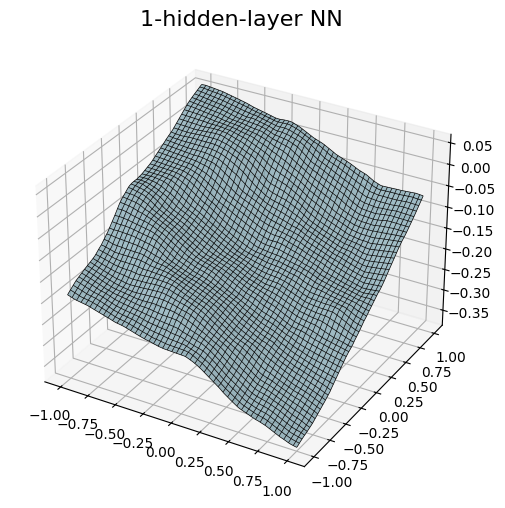

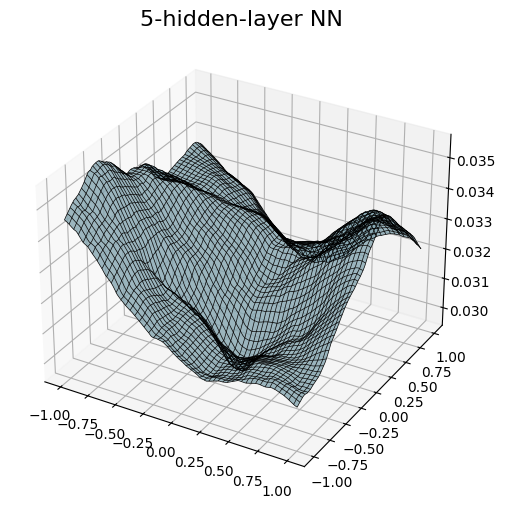

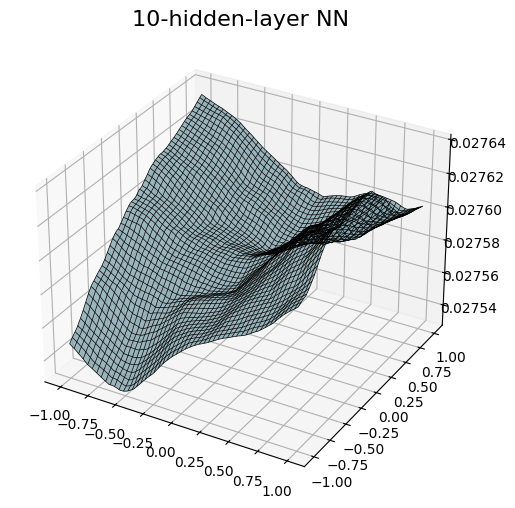

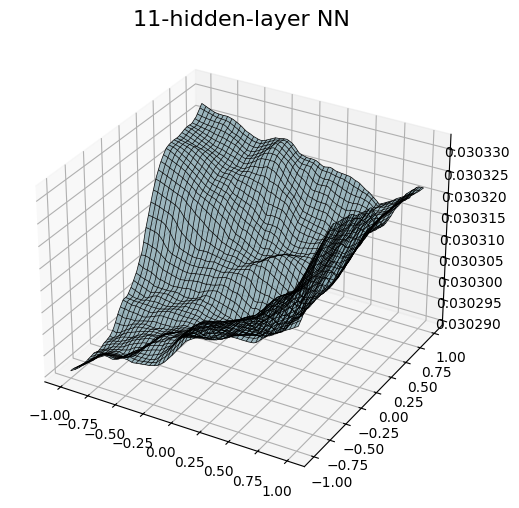

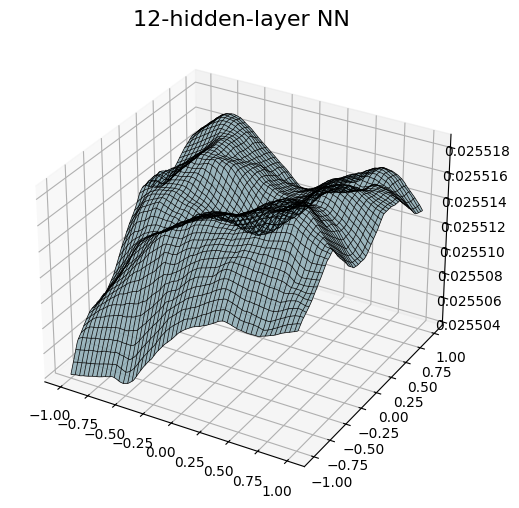

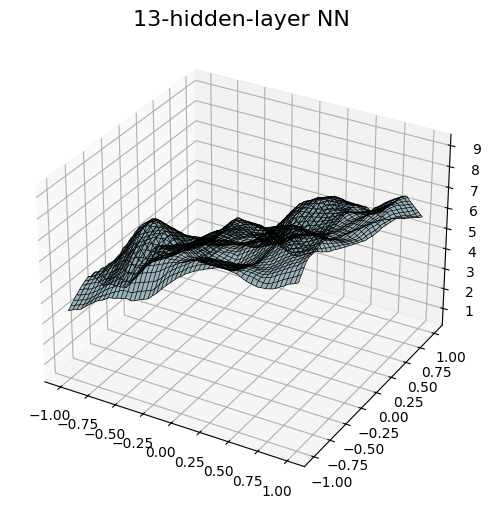

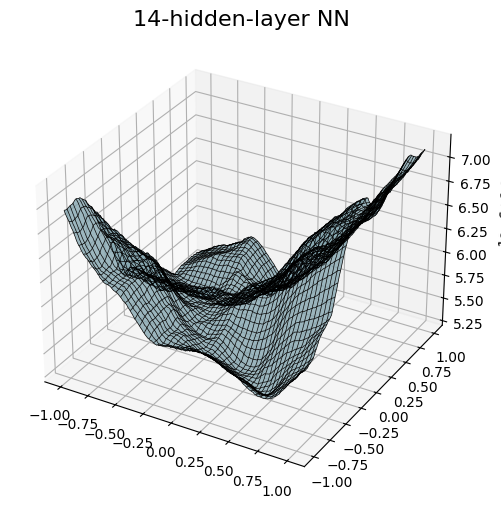

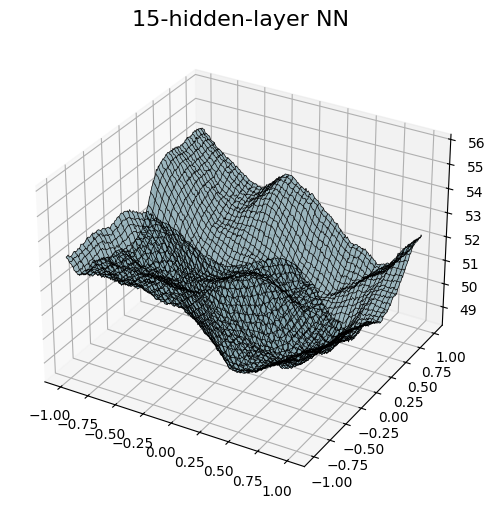

In [41]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import random

# Fix random seeds
SEED = 94
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # If using CUDA
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False  # Ensures full determinism

# カラーパレット
color_palette = {
    "white": "#FFFFFF",
    "light_gray": "#D3D3D3",
    "gray": "#808080",
    "black": "#000000",
    "green": "#008000",
    "blue": "#0000FF",
    "light_blue": "#ADD8E6",
    "light_light_blue": "#E0FFFF",
    "yellow": "#FFFF00",
    "orange": "#FFA500",
    "dark_orange": "#FF8C00",
    "purple": "#800080",
}

# ニューラルネットワークの定義（最終層は Linear）
class IncrementalNN(nn.Module):
    def __init__(self, input_dim=2, width=100, output_dim=1):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(input_dim, width)])
        self.activations = [nn.ReLU()]
        self.output_layer = nn.Linear(width, output_dim)  # Linear 出力

    def add_layer(self):
        self.layers.append(nn.Linear(100, 100))
        self.activations.append(nn.ReLU())

    def forward(self, x):
        for layer, activation in zip(self.layers, self.activations):
            x = activation(layer(x))
        return self.output_layer(x)  # Linear 出力


# 3Dサーフェスプロットの関数
def plot_surface(X, Y, Z, interim_depth):
    """
    入力層と出力層のみのとき（interim_depth=0），隠れ1層であると数える．
    つまり n_hidden_layer=interim_depth+1 である
    """
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, Z, color=color_palette["light_blue"], alpha=0.8)
    ax.plot_wireframe(X, Y, Z, color=color_palette["black"], linewidth=0.5)

    plt.title(f"{interim_depth+1}-hidden-layer NN", fontsize=16, color=color_palette["black"])
    plt.show()


# 入力データのグリッド作成
x_range = np.linspace(-1, 1, 200)
y_range = np.linspace(-1, 1, 200)
X, Y = np.meshgrid(x_range, y_range)
xy_tensor = torch.tensor(np.c_[X.ravel(), Y.ravel()], dtype=torch.float32)

# モデルの初期化
model = IncrementalNN()

# 階層を増やしながらプロット
hidden_layers = [1, 5, 10, 11, 12, 13, 14, 15]
for imterim_layer in range(max(hidden_layers)):
    if (imterim_layer+1) in hidden_layers:
        Z = model(xy_tensor).detach().numpy().reshape(X.shape)
        plot_surface(X, Y, Z, imterim_layer)

    model.add_layer()  # 層を追加

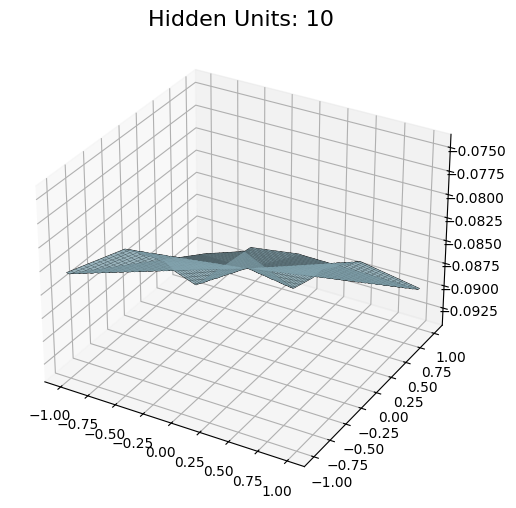

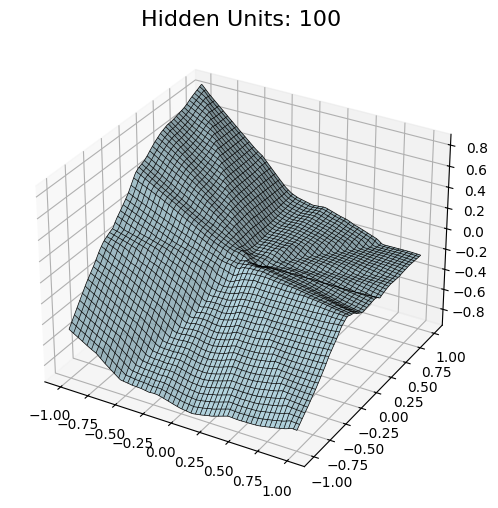

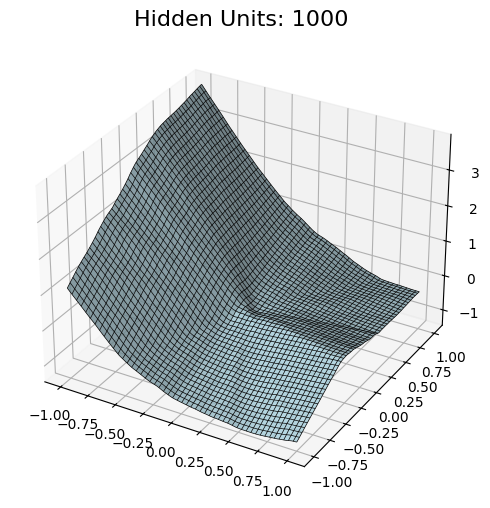

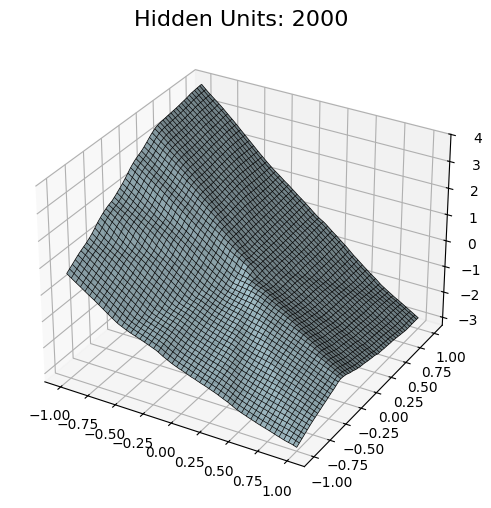

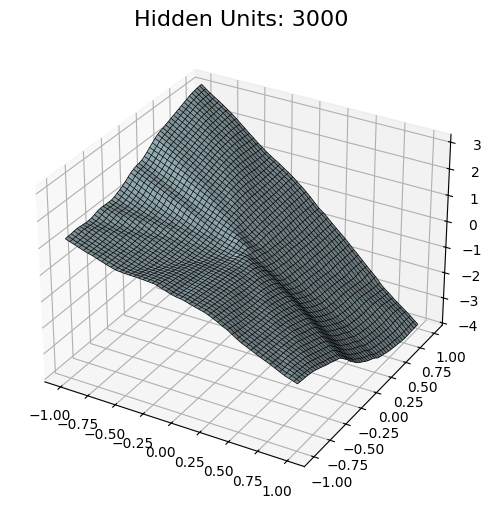

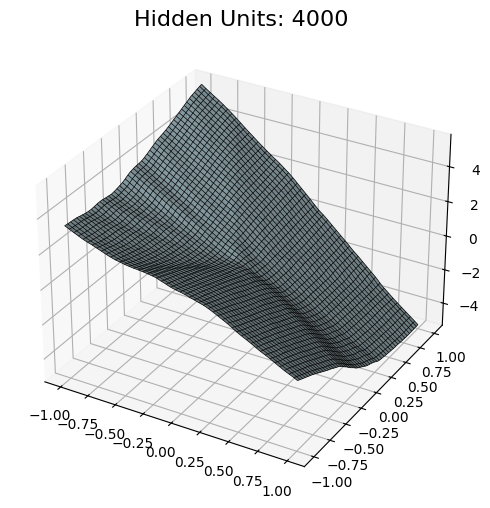

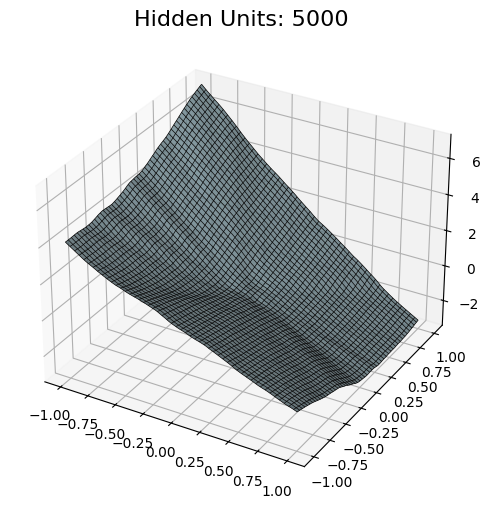

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import random

# Fix random seeds
SEED = 94
random.seed(SEED)
np.random.seed(SEED)

# カラーパレット
color_palette = {
    "white": "#FFFFFF",
    "light_gray": "#D3D3D3",
    "gray": "#808080",
    "black": "#000000",
    "green": "#008000",
    "blue": "#0000FF",
    "light_blue": "#ADD8E6",
    "light_light_blue": "#E0FFFF",
    "yellow": "#FFFF00",
    "orange": "#FFA500",
    "dark_orange": "#FF8C00",
    "purple": "#800080",
}

# ReLU 活性化関数
def relu(x):
    return np.maximum(0, x)

# ニューラルネットワークの定義（1隠れ層のみ）
def forward_nn(X, W1, b1, W2, b2):
    hidden = relu(np.dot(X, W1) + b1)  # 隠れ層
    output = np.dot(hidden, W2) + b2  # 出力層
    return output

# 3Dプロット関数
def plot_surface(X, Y, Z, units):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, color=color_palette["light_blue"], alpha=0.8)
    ax.plot_wireframe(X, Y, Z, color=color_palette["black"], linewidth=0.5)
    plt.title(f"Hidden Units: {units}", fontsize=16, color=color_palette["black"])
    plt.show()

# 入力データのグリッド作成
x_range = np.linspace(-1, 1, 200)
y_range = np.linspace(-1, 1, 200)
X, Y = np.meshgrid(x_range, y_range)
XY = np.c_[X.ravel(), Y.ravel()]

# 初期の重みとバイアスを設定（ユニット10個）
initial_units = 10
W1 = np.random.randn(2, initial_units) * 0.1
b1 = np.zeros((1, initial_units))
W2 = np.random.randn(initial_units, 1) * 0.1
b2 = np.random.randn(1, 1) * 0.1

# 試すユニット数のリスト
unit_sizes = [10, 100, 1000, 2000, 3000, 4000, 5000]

for units in unit_sizes:
    if units > W1.shape[1]:
        new_units = units - W1.shape[1]
        W1_new = np.random.randn(2, new_units) * np.sqrt(2 / 2)
        b1_new = np.random.randn(1, new_units) * 0.1
        W2_new = np.random.randn(new_units, 1) * np.sqrt(2 / new_units)
        
        W1 = np.hstack([W1, W1_new])
        b1 = np.hstack([b1, b1_new])
        W2 = np.vstack([W2, W2_new])
    
    # NN の順伝播
    Z = forward_nn(XY, W1, b1, W2, b2)
    Z = Z.reshape(X.shape)
    
    # プロット
    plot_surface(X, Y, Z, units)
